<a href="https://colab.research.google.com/github/HimanshiChoubal/Major_Project/blob/master/Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pennylane pennylane-qiskit qiskit qiskit-aer torch torchvision scikit-learn matplotlib scipy

import os, math, time, random
import numpy as np
import torch, torch.nn as nn
import pennylane as qml
import qiskit, sklearn, matplotlib
import matplotlib.pyplot as plt

CFG = dict(
    seed=42,
    img_size=32,        # satellite patch size (pixels)
    n_channels=4,       # R, G, B, NIR
    win=8,              # window size -> (32/8)^2 = 16 windows per patch
    n_qubits=4,         # PCA components == qubits
    n_samples=1000,     # total synthetic patches (balanced)
)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
set_seed(CFG["seed"])

print(f"PennyLane {qml.__version__} | Qiskit {qiskit.__version__} | Torch {torch.__version__} | sklearn {sklearn.__version__}")
print("CUDA available:", torch.cuda.is_available(), "(circuits run on CPU simulators; GPU only helps the classical head)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 797.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB

Dataset: (1000, 4, 32, 32) | class balance: [500, 500]


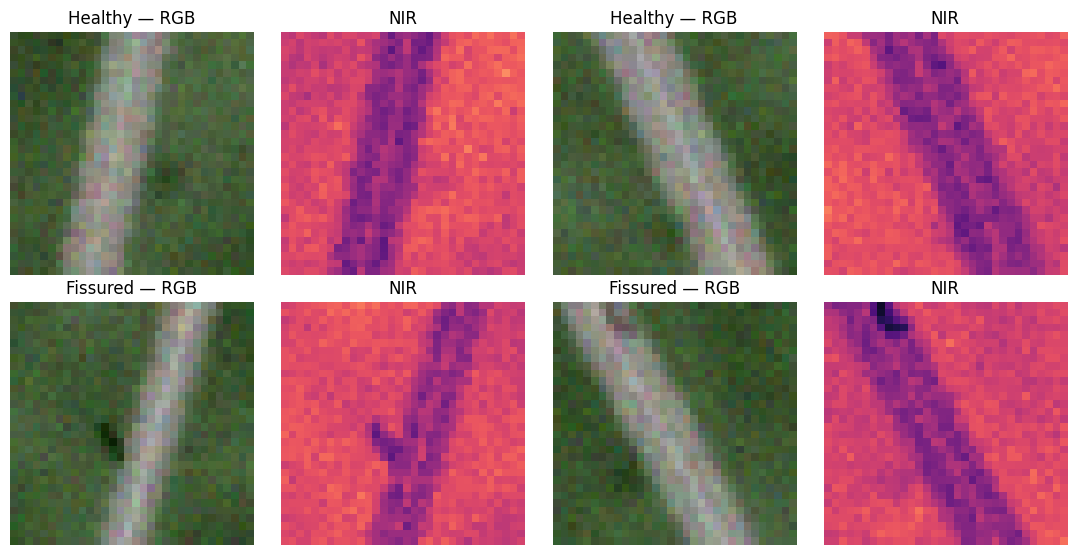

In [ ]:
from scipy.ndimage import gaussian_filter

BANDS = ["R", "G", "B", "NIR"]
SIG_TERRAIN  = np.array([0.25, 0.35, 0.20, 0.60])   # vegetation: high NIR
SIG_CONCRETE = np.array([0.55, 0.55, 0.52, 0.38])   # concrete/asphalt
CRACK_DEPTH  = np.array([0.18, 0.18, 0.18, 0.28])   # per-band darkening on fissures
CLOUD_COLOR  = np.array([0.90, 0.90, 0.92, 0.80])

def _smooth_noise(rng, size, sigma):
    n = gaussian_filter(rng.normal(size=(size, size)), sigma)
    return (n - n.min()) / (n.max() - n.min() + 1e-8)

def _deck(rng, size):
    """Linear infrastructure deck. Returns soft mask, orientation, distance-to-centerline."""
    ang = rng.uniform(0, np.pi); width = rng.uniform(3.0, 5.0)
    yy, xx = np.mgrid[0:size, 0:size]
    cx, cy = size / 2 + rng.uniform(-3, 3), size / 2 + rng.uniform(-3, 3)
    d = np.abs((xx - cx) * np.sin(ang) - (yy - cy) * np.cos(ang))
    return gaussian_filter((d < width).astype(float), 0.8), ang, d

def _fissures(rng, size, mask, ang):
    """1-2 thin random-walk cracks seeded inside the deck."""
    c = np.zeros((size, size))
    ys, xs = np.nonzero(mask > 0.5)
    for _ in range(rng.integers(1, 3)):
        k = rng.integers(len(ys)); y, x = float(ys[k]), float(xs[k])
        heading = ang + rng.uniform(-0.6, 0.6) + (np.pi / 2 if rng.random() < 0.5 else 0.0)
        for _ in range(rng.integers(6, 14)):
            heading += rng.normal(0, 0.35)
            y += np.sin(heading); x += np.cos(heading)
            iy, ix = int(round(y)), int(round(x))
            if 0 <= iy < size and 0 <= ix < size:
                c[iy, ix] = 1.0
    return np.clip(gaussian_filter(c, 0.6) * 3.0, 0, 1)

def generate_patch(label, rng, size=32, noise_sigma=0.03, cloud_prob=0.4):
    terrain = _smooth_noise(rng, size, 4)
    mask, ang, d = _deck(rng, size)
    img = np.zeros((4, size, size))
    for ch in range(4):
        base = SIG_TERRAIN[ch] + 0.12 * (terrain - 0.5)
        deck = gaussian_filter(SIG_CONCRETE[ch] + 0.04 * rng.normal(size=(size, size)), 0.5)
        img[ch] = (1 - mask) * base + mask * deck
    # hard negatives present in BOTH classes: lane marking + shadow blob
    lane = np.exp(-(d ** 2) / (2 * 0.6 ** 2)) * mask * rng.uniform(0.05, 0.12)
    img += lane[None]
    if rng.random() < 0.5:
        blob = np.zeros((size, size)); blob[rng.integers(4, size - 4), rng.integers(4, size - 4)] = 1
        img -= (gaussian_filter(blob, 2.0) / gaussian_filter(blob, 2.0).max() * 0.10)[None]
    # class 1: micro-fissures
    if label == 1:
        img -= _fissures(rng, size, mask, ang)[None] * CRACK_DEPTH[:, None, None]
    # clouds (all bands) then Gaussian sensor noise
    if rng.random() < cloud_prob:
        cl = _smooth_noise(rng, size, rng.uniform(3, 6))
        alpha = np.clip((cl - 0.55) * 3, 0, 1) * rng.uniform(0.3, 0.7)
        img = (1 - alpha) * img + alpha * CLOUD_COLOR[:, None, None]
    img += rng.normal(0, noise_sigma, img.shape)
    return np.clip(img, 0, 1).astype(np.float32)

def generate_dataset(n, seed):
    rng = np.random.default_rng(seed)
    y = np.array([0, 1] * (n // 2))
    rng.shuffle(y)
    X = np.stack([generate_patch(int(l), rng, CFG["img_size"]) for l in y])
    return torch.from_numpy(X), torch.from_numpy(y).long()

X_raw, y_raw = generate_dataset(CFG["n_samples"], CFG["seed"])
print("Dataset:", tuple(X_raw.shape), "| class balance:", torch.bincount(y_raw).tolist())

# Visual sanity check: RGB composite and NIR for each class
fig, ax = plt.subplots(2, 4, figsize=(11, 5.6))
for r, cls in enumerate([0, 1]):
    idx = (y_raw == cls).nonzero().flatten()[:2]
    for k, i in enumerate(idx):
        ax[r, 2 * k].imshow(X_raw[i, :3].permute(1, 2, 0).numpy())
        ax[r, 2 * k].set_title(f"{'Healthy' if cls == 0 else 'Fissured'} — RGB")
        ax[r, 2 * k + 1].imshow(X_raw[i, 3].numpy(), cmap="magma", vmin=0, vmax=1)
        ax[r, 2 * k + 1].set_title("NIR")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

def extract_windows(X, win):
    """(N,C,H,W) -> (N, n_windows, C*win*win) via non-overlapping unfold."""
    p = X.unfold(2, win, win).unfold(3, win, win)          # N,C,gh,gw,win,win
    N, C, gh, gw, _, _ = p.shape
    return p.permute(0, 2, 3, 1, 4, 5).reshape(N, gh * gw, C * win * win)

def preprocess(X, y, cfg):
    idx = np.arange(len(y))
    tr, tmp = train_test_split(idx, test_size=0.4, stratify=y.numpy(), random_state=cfg["seed"])
    va, te = train_test_split(tmp, test_size=0.5, stratify=y.numpy()[tmp], random_state=cfg["seed"])

    # (2) per-band z-score, training statistics only
    mu = X[tr].mean(dim=(0, 2, 3), keepdim=True)
    sd = X[tr].std(dim=(0, 2, 3), keepdim=True) + 1e-6
    Xz = (X - mu) / sd

    # (3) window extraction
    W = extract_windows(Xz, cfg["win"])                    # N,16,256
    n_win, D = W.shape[1], W.shape[2]

    # (4) PCA fit on training windows only
    pca = PCA(n_components=cfg["n_qubits"], random_state=cfg["seed"])
    pca.fit(W[tr].reshape(-1, D).numpy())
    Z = pca.transform(W.reshape(-1, D).numpy()).reshape(len(y), n_win, cfg["n_qubits"])

    # (5) robust scaling to [0, pi] using training percentiles
    lo = np.percentile(Z[tr].reshape(-1, cfg["n_qubits"]), 1, axis=0)
    hi = np.percentile(Z[tr].reshape(-1, cfg["n_qubits"]), 99, axis=0)
    Zq = np.clip((Z - lo) / (hi - lo + 1e-8), 0, 1) * np.pi

    Zq = torch.from_numpy(Zq).float()
    out = {k: (Zq[i], y[i]) for k, i in zip(["train", "val", "test"], [tr, va, te])}
    out["idx"] = dict(train=tr, val=va, test=te)
    out["pca"] = pca; out["n_windows"] = n_win
    return out

DATA = preprocess(X_raw, y_raw, CFG)
for k in ["train", "val", "test"]:
    print(f"{k:5s}: features {tuple(DATA[k][0].shape)}  (samples, windows, qubits)  labels {tuple(DATA[k][1].shape)}")
print("PCA explained variance ratio:", np.round(DATA["pca"].explained_variance_ratio_, 3),
      "| total:", round(float(DATA["pca"].explained_variance_ratio_.sum()), 3))
print("Feature range:", float(DATA["train"][0].min()), "to", float(DATA["train"][0].max()))

train: features (600, 16, 4)  (samples, windows, qubits)  labels (600,)
val  : features (200, 16, 4)  (samples, windows, qubits)  labels (200,)
test : features (200, 16, 4)  (samples, windows, qubits)  labels (200,)
PCA explained variance ratio: [0.495 0.111 0.102 0.097] | total: 0.805
Feature range: 0.0 to 3.1415927410125732


z: (2, 16) | saliency: (2, 16, 4) | trainable quantum params: 66


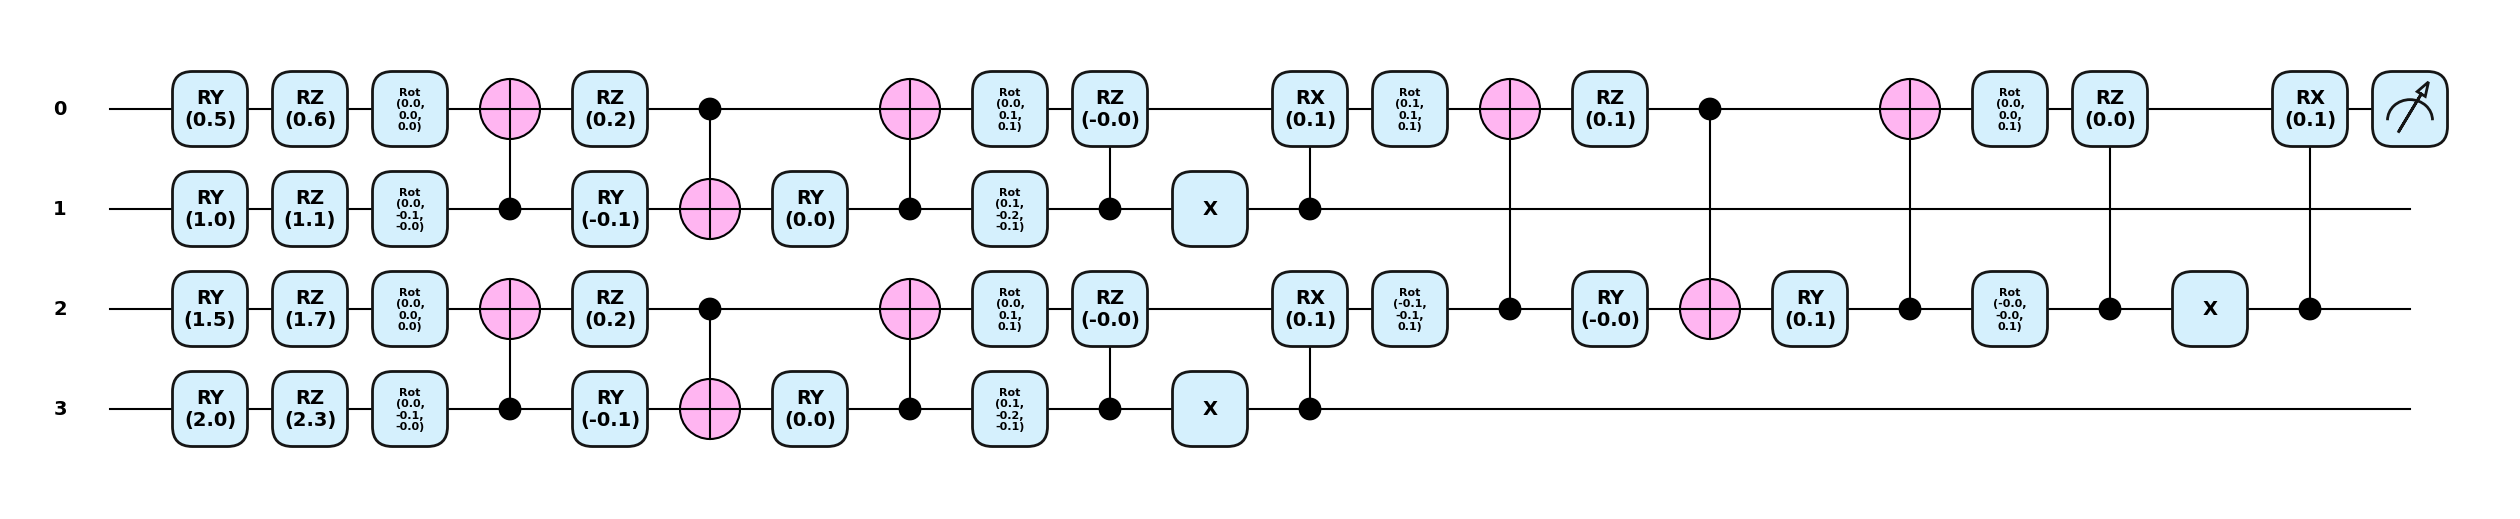

In [ ]:
N_Q = CFG["n_qubits"]
CONV1_PAIRS = [(0, 1), (2, 3), (1, 2), (3, 0)]
POOL1 = [(1, 0), (3, 2)]        # (source -> sink), sources traced out
CONV2_PAIRS = [(0, 2)]
POOL2 = [(2, 0)]
N_SU4, N_POOL = 15, 2

# ---------------- building blocks ----------------
def hybrid_encode(x, wires):
    """Angle (RY on magnitude) + amplitude-style (RZ on unit-normalised direction) encoding.
    x: (B,4) tensor of angles in [0, pi]; parameter broadcasting handles the batch."""
    amp = x / torch.linalg.norm(x, dim=-1, keepdim=True).clamp_min(1e-6)
    for i, w in enumerate(wires):
        qml.RY(x[..., i], wires=w)
        qml.RZ(np.pi * amp[..., i], wires=w)

def su4_conv(w, a, b):
    """General two-qubit SU(4) unitary: 12 local + 3 nonlocal parameters, 3 CNOTs."""
    qml.Rot(w[0], w[1], w[2], wires=a); qml.Rot(w[3], w[4], w[5], wires=b)
    qml.CNOT(wires=[b, a])
    qml.RZ(w[6], wires=a); qml.RY(w[7], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RY(w[8], wires=b)
    qml.CNOT(wires=[b, a])
    qml.Rot(w[9], w[10], w[11], wires=a); qml.Rot(w[12], w[13], w[14], wires=b)

def quantum_pool(w, src, sink):
    """Controlled-rotation pooling; `src` is simply never measured again (partial trace)."""
    qml.CRZ(w[0], wires=[src, sink])
    qml.PauliX(wires=src)
    qml.CRX(w[1], wires=[src, sink])

def aqfs_block(x, theta, gamma, psi, zeta):
    """Adaptive Quantum Feature Saliency: data re-uploading + entanglement ring.
    theta, gamma, psi, zeta: (L, 4) trainable tensors."""
    for l in range(theta.shape[0]):
        for i in range(N_Q):
            qml.RY(theta[l, i] + gamma[l, i] * x[..., i], wires=i)   # adaptive, data-dependent angle
            qml.RZ(psi[l, i], wires=i)
        for i in range(N_Q):
            qml.CNOT(wires=[i, (i + 1) % N_Q])                       # entangling ring
        for i in range(N_Q):
            qml.CRZ(zeta[l, i], wires=[i, (i + 1) % N_Q])            # learnable coupling strengths

def _noise(p, wires):
    if p > 0:
        for w in wires:
            qml.DepolarizingChannel(p, wires=w)

# ---------------- trainable module ----------------
class AQFSQCNN(nn.Module):
    """Per-window quantum feature extractor.
    forward(x): x (B, n_windows, 4) -> z (B, n_windows), s (B, n_windows, 4)."""
    def __init__(self, n_aqfs_layers=2, noise_p=0.0):
        super().__init__()
        self.noise_p = noise_p
        init = lambda *s: nn.Parameter(0.1 * torch.randn(*s))
        self.conv1_w, self.conv2_w = init(N_SU4), init(N_SU4)
        self.pool1_w, self.pool2_w = init(N_POOL), init(N_POOL)
        self.aq_theta, self.aq_gamma = init(n_aqfs_layers, N_Q), nn.Parameter(torch.ones(n_aqfs_layers, N_Q) + 0.1 * torch.randn(n_aqfs_layers, N_Q))
        self.aq_psi, self.aq_zeta = init(n_aqfs_layers, N_Q), init(n_aqfs_layers, N_Q)

        dev = qml.device("default.mixed" if noise_p > 0 else "default.qubit", wires=N_Q)
        p = noise_p

        @qml.qnode(dev, interface="torch", diff_method="backprop")
        def core(x, c1, c2, p1, p2):
            hybrid_encode(x, range(N_Q))
            for a, b in CONV1_PAIRS: su4_conv(c1, a, b)
            _noise(p, range(N_Q))
            for s, t in POOL1: quantum_pool(p1, s, t)
            for a, b in CONV2_PAIRS: su4_conv(c2, a, b)
            _noise(p, [0, 2])
            for s, t in POOL2: quantum_pool(p2, s, t)
            return qml.expval(qml.PauliZ(0))

        @qml.qnode(dev, interface="torch", diff_method="backprop")
        def saliency(x, th, ga, ps, ze):
            hybrid_encode(x, range(N_Q))
            aqfs_block(x, th, ga, ps, ze)
            _noise(p, range(N_Q))
            return [qml.expval(qml.PauliZ(i)) for i in range(N_Q)]

        self._core, self._sal = core, saliency

    def forward(self, x):
        B, P, _ = x.shape
        xf = x.reshape(B * P, N_Q)
        z = self._core(xf, self.conv1_w, self.conv2_w, self.pool1_w, self.pool2_w)
        s = self._sal(xf, self.aq_theta, self.aq_gamma, self.aq_psi, self.aq_zeta)
        s = torch.stack(list(s), dim=-1) if isinstance(s, (list, tuple)) else s
        return z.float().reshape(B, P), s.float().reshape(B, P, N_Q)

# ---------------- smoke test + circuit drawing ----------------
qm = AQFSQCNN()
n_q_params = sum(p.numel() for p in qm.parameters())
z, s = qm(DATA["train"][0][:2])
print("z:", tuple(z.shape), "| saliency:", tuple(s.shape), "| trainable quantum params:", n_q_params)

_dev = qml.device("default.qubit", wires=N_Q)
@qml.qnode(_dev)
def _draw(x):
    hybrid_encode(x, range(N_Q))
    for a, b in CONV1_PAIRS[:2]: su4_conv(qm.conv1_w.detach(), a, b)
    for s_, t_ in POOL1: quantum_pool(qm.pool1_w.detach(), s_, t_)
    su4_conv(qm.conv2_w.detach(), 0, 2); quantum_pool(qm.pool2_w.detach(), 2, 0)
    return qml.expval(qml.PauliZ(0))
fig, _ = qml.draw_mpl(_draw, decimals=1, style="pennylane")(torch.tensor([0.5, 1.0, 1.5, 2.0]))
plt.show()

In [ ]:
class HybridQCNNNet(nn.Module):
    def __init__(self, noise_p=0.0, n_aqfs_layers=2):
        super().__init__()
        self.quantum = AQFSQCNN(n_aqfs_layers, noise_p)
        self.log_tau = nn.Parameter(torch.zeros(1))                 # learnable attention temperature
        self.head = nn.Sequential(nn.Linear(1 + N_Q, 16), nn.ReLU(), nn.Dropout(0.1), nn.Linear(16, 1))

    def forward(self, x, return_attn=False):
        z, s = self.quantum(x)                                      # (B,P), (B,P,4)
        alpha = torch.softmax(s.sum(-1) * torch.exp(-self.log_tau), dim=1)   # (B,P) window attention
        feats = torch.cat([z.unsqueeze(-1), s], dim=-1)             # (B,P,5)
        pooled = (alpha.unsqueeze(-1) * feats).sum(1)               # (B,5)
        logit = self.head(pooled).squeeze(-1)
        return (logit, alpha) if return_attn else logit

model = HybridQCNNNet()
count = lambda m: sum(p.numel() for p in m.parameters() if p.requires_grad)
tiny_attn = nn.TransformerEncoderLayer(d_model=16, nhead=2, dim_feedforward=32, batch_first=True)
print(f"Quantum core + AQFS parameters : {count(model.quantum)}")
print(f"Classical head + temperature   : {count(model) - count(model.quantum)}")
print(f"Total hybrid model             : {count(model)}")
print(f"Reference: ONE tiny Transformer encoder layer (d=16, 2 heads, ff=32): {count(tiny_attn)}")
print("Note: this compares parameter counts only; accuracy parity must be shown by ablation.")

Quantum core + AQFS parameters : 66
Classical head + temperature   : 114
Total hybrid model             : 180
Reference: ONE tiny Transformer encoder layer (d=16, 2 heads, ff=32): 2224
Note: this compares parameter counts only; accuracy parity must be shown by ablation.


epoch 01/8 | loss 0.6908 | val acc 0.655 | 2.6s
epoch 02/8 | loss 0.6857 | val acc 0.500 | 3.0s
epoch 03/8 | loss 0.6808 | val acc 0.550 | 3.5s
epoch 04/8 | loss 0.6677 | val acc 0.605 | 2.6s
epoch 05/8 | loss 0.6531 | val acc 0.640 | 3.0s
epoch 06/8 | loss 0.6395 | val acc 0.645 | 2.7s
epoch 07/8 | loss 0.6160 | val acc 0.635 | 3.4s
epoch 08/8 | loss 0.6081 | val acc 0.630 | 2.8s


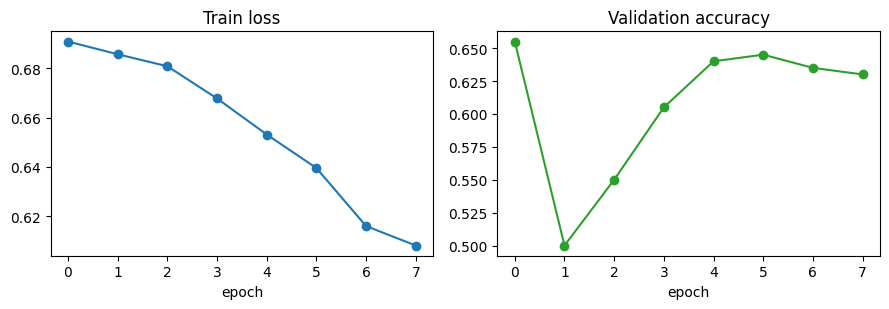

In [ ]:
from sklearn.metrics import accuracy_score

def predict(model, X, bs=64):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), bs):
            out.append(torch.sigmoid(model(X[i:i + bs])))
    return torch.cat(out).numpy()

def train(model, data, epochs=8, bs=32, lr=0.05, seed=CFG["seed"]):
    set_seed(seed)
    Xtr, ytr = data["train"]; Xva, yva = data["val"]
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    lossf = nn.BCEWithLogitsLoss()
    hist = dict(loss=[], val_acc=[]); best, best_state = 0.0, None
    for ep in range(epochs):
        model.train(); perm = torch.randperm(len(Xtr)); run, t0 = 0.0, time.time()
        for i in range(0, len(Xtr), bs):
            b = perm[i:i + bs]
            opt.zero_grad()
            loss = lossf(model(Xtr[b]), ytr[b].float())
            loss.backward(); opt.step()
            run += loss.item() * len(b)
        sched.step()
        acc = accuracy_score(yva.numpy(), predict(model, Xva) > 0.5)
        hist["loss"].append(run / len(Xtr)); hist["val_acc"].append(acc)
        if acc >= best: best, best_state = acc, {k: v.clone() for k, v in model.state_dict().items()}
        print(f"epoch {ep + 1:02d}/{epochs} | loss {hist['loss'][-1]:.4f} | val acc {acc:.3f} | {time.time() - t0:.1f}s")
    model.load_state_dict(best_state)
    return hist

hist = train(model, DATA)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(hist["loss"], marker="o"); ax[0].set_title("Train loss"); ax[0].set_xlabel("epoch")
ax[1].plot(hist["val_acc"], marker="o", color="tab:green"); ax[1].set_title("Validation accuracy"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

Test acc 0.640 | F1 0.690 | ROC-AUC 0.676


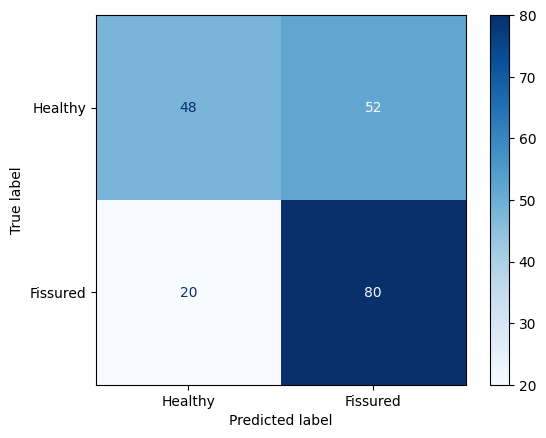

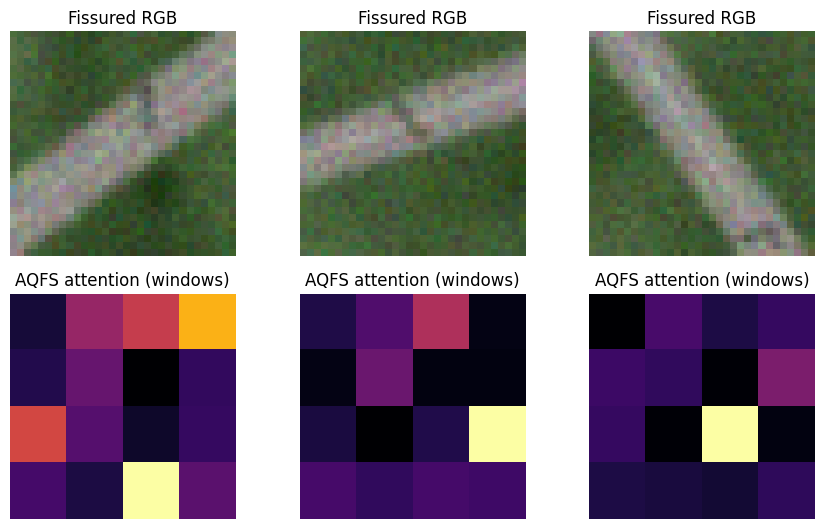

depolarizing p=0.0    -> acc 0.588  (n=80)
depolarizing p=0.005  -> acc 0.588  (n=80)
depolarizing p=0.02   -> acc 0.600  (n=80)
depolarizing p=0.05   -> acc 0.575  (n=80)


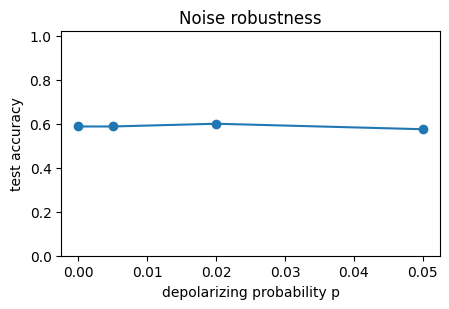

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

Xte, yte = DATA["test"]
p_te = predict(model, Xte)
print(f"Test acc {accuracy_score(yte.numpy(), p_te > 0.5):.3f} | F1 {f1_score(yte.numpy(), p_te > 0.5):.3f} | "
      f"ROC-AUC {roc_auc_score(yte.numpy(), p_te):.3f}")
ConfusionMatrixDisplay(confusion_matrix(yte.numpy(), p_te > 0.5), display_labels=["Healthy", "Fissured"]).plot(cmap="Blues")
plt.show()

# ---- AQFS window-attention maps on fissured test samples ----
model.eval()
te_idx = DATA["idx"]["test"]; g = CFG["img_size"] // CFG["win"]
pos = (yte == 1).nonzero().flatten()[:3]
with torch.no_grad():
    _, alpha = model(Xte[pos], return_attn=True)
fig, ax = plt.subplots(2, 3, figsize=(9, 5.4))
for k, i in enumerate(pos):
    ax[0, k].imshow(X_raw[te_idx[i], :3].permute(1, 2, 0).numpy()); ax[0, k].set_title("Fissured RGB")
    ax[1, k].imshow(alpha[k].reshape(g, g).numpy(), cmap="inferno"); ax[1, k].set_title("AQFS attention (windows)")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

# ---- Depolarizing-noise robustness (trained weights re-used on a noisy density-matrix simulator) ----
n_eval = 80
noise_levels = [0.0, 0.005, 0.02, 0.05]
accs = []
for p in noise_levels:
    m = HybridQCNNNet(noise_p=p); m.load_state_dict(model.state_dict())
    accs.append(accuracy_score(yte[:n_eval].numpy(), predict(m, Xte[:n_eval], bs=40) > 0.5))
    print(f"depolarizing p={p:<6} -> acc {accs[-1]:.3f}  (n={n_eval})")
plt.figure(figsize=(4.6, 3.2)); plt.plot(noise_levels, accs, marker="o")
plt.xlabel("depolarizing probability p"); plt.ylabel("test accuracy"); plt.title("Noise robustness"); plt.ylim(0, 1.02)
plt.tight_layout(); plt.show()
# Hardware/Qiskit route (not run here): qml.device("qiskit.aer", wires=4, noise_model=...) via pennylane-qiskit.